# 04 — Evaluation

SHAP analysis + feature importance dla najlepszego modelu (T=1h, VS+RB+BG).

- **Faza 1:** Wczytanie modelu XGBoost + danych
- **Faza 2:** Feature importance (gain) + porównanie z publikacją (Supplemental Table 1)
- **Faza 3:** SHAP — beeswarm + bar chart
- **Faza 4:** SHAP dependence plots (replikacja Fig. 3)
- **Faza 5:** SHAP waterfall — 2 przykładowi pacjenci

> Uruchamiaj z katalogu `THS_Prediction/` lub upewnij się, że `config.py` jest na `sys.path`.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

try:
    import shap
    print(f"SHAP version: {shap.__version__}")
except ImportError:
    print("SHAP not installed. Run: pip install shap")

print(f"XGBoost: {xgb.__version__}")
print("Environment ready.")


SHAP version: 0.48.0
XGBoost: 3.2.0
Environment ready.


## Parametry

In [2]:
# Model do analizy
MODEL_KEY   = 'T1h_VS_RB_BG'
SHAP_SAMPLE = 500
RANDOM_SEED = config.RANDOM_SEED

META_COLS = ['HADM_ID','SUBJECT_ID','TIME_WINDOW','REFERENCE_TIME',
             'ONSET_TIME','LABEL','HOURS_TO_SHOCK']

# Kategorie features — per publikacja (bez SpO2, który nie był dostępny w MIMIC)
FEATURE_CATEGORIES = {
    'Vital Signs':   ['HR','SBP','DBP','RESP','TEMP'],   # 5 × 3 timesteps = 15
    'Routine Blood': ['Hemoglobin','Hematocrit','WBC','RBC','Platelets'],  # 5
    'Blood Gas':     ['pH','PaCO2','PaO2','Lactate','Base_Excess','TCO2'], # 6
}

# PUB_IMPORTANCE z Supplemental Table 1 — renormalizowane do 3 kategorii
# (publikacja raportuje 5 kategorii; suma VS+RB+BG = 0.292+0.249+0.225 = 0.766)
_pub_sum = 0.292 + 0.249 + 0.225
PUB_IMPORTANCE = {
    'Vital Signs':   0.292 / _pub_sum,   # 0.3812
    'Routine Blood': 0.249 / _pub_sum,   # 0.3251
    'Blood Gas':     0.225 / _pub_sum,   # 0.2938
}

FEATURE_DISPLAY = {
    'HR_t0':'HR (t0)', 'HR_t1':'HR (t1)', 'HR_t2':'HR (t2)',
    'SBP_t0':'SBP (t0)', 'SBP_t1':'SBP (t1)', 'SBP_t2':'SBP (t2)',
    'DBP_t0':'DBP (t0)', 'DBP_t1':'DBP (t1)', 'DBP_t2':'DBP (t2)',
    'RESP_t0':'RESP (t0)', 'RESP_t1':'RESP (t1)', 'RESP_t2':'RESP (t2)',
    'TEMP_t0':'TEMP (t0)', 'TEMP_t1':'TEMP (t1)', 'TEMP_t2':'TEMP (t2)',
    'Hemoglobin':'Hb', 'Hematocrit':'Hct', 'WBC':'WBC',
    'RBC':'RBC', 'Platelets':'PLT',
    'pH':'pH', 'PaCO2':'PaCO2', 'PaO2':'PaO2',
    'Lactate':'Lactate', 'Base_Excess':'BE', 'TCO2':'TCO2',
}

CAT_COLORS = {
    'Vital Signs':   '#1f77b4',
    'Routine Blood': '#2ca02c',
    'Blood Gas':     '#d62728',
    'Other':         '#7f7f7f',
}

def assign_category(feat_name):
    base = feat_name.split('_t')[0]
    for cat, feats in FEATURE_CATEGORIES.items():
        if base in feats:
            return cat
    return 'Other'

print(f"MODEL_KEY:      {MODEL_KEY}")
print(f"SHAP_SAMPLE:    {SHAP_SAMPLE}")
print(f"\nPUB_IMPORTANCE (renormalized to 3 categories):")
for k, v in PUB_IMPORTANCE.items():
    print(f"  {k:<16}: {v:.4f}")


MODEL_KEY:      T1h_VS_RB_BG
SHAP_SAMPLE:    500

PUB_IMPORTANCE (renormalized to 3 categories):
  Vital Signs     : 0.3812
  Routine Blood   : 0.3251
  Blood Gas       : 0.2937


## Faza 1 — Wczytanie modelu i danych

In [3]:
print("Loading model...")
model = joblib.load(config.MODELS_DIR / f'xgb_{MODEL_KEY}_final.joblib')
print(f"  n_estimators: {model.n_estimators}")
print(f"  max_depth:    {model.max_depth}")
print(f"  learning_rate:{model.learning_rate}")

print("\nLoading feature names...")
feat_path = config.MODELS_DIR / f'feature_names_{MODEL_KEY}.txt'
feature_names = feat_path.read_text().strip().split('\n')
print(f"  {len(feature_names)} features: {feature_names[:5]}...")

print("\nLoading dataset...")
df = pd.read_csv(config.IMPUTED_DIR / f'features_T1h_VS_RB_BG_imputed.csv')
drop_cols = [c for c in META_COLS + ['LABEL'] if c in df.columns]
X = df.drop(columns=drop_cols)[feature_names].values.astype(float)
y = df['LABEL'].values.astype(int)
print(f"  n={len(df):,} | THS={y.sum():,} | non-THS={(y==0).sum():,}")

# SHAP sample
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X), size=min(SHAP_SAMPLE, len(X)), replace=False)
X_sample   = X[sample_idx]
y_sample   = y[sample_idx]
print(f"\nSHAP sample: n={len(X_sample)} | THS={y_sample.sum()} | non-THS={(y_sample==0).sum()}")


Loading model...
  n_estimators: None
  max_depth:    None
  learning_rate:None

Loading feature names...
  26 features: ['HR_t0', 'HR_t1', 'HR_t2', 'SBP_t0', 'SBP_t1']...

Loading dataset...
  n=1,733 | THS=236 | non-THS=1,497

SHAP sample: n=500 | THS=66 | non-THS=434


## Faza 2 — Feature importance (Gain)

Publikacja używa *average gain* XGBoost (Fig. 1C, Supplemental Table 1).


In [4]:
print("Computing XGBoost gain importance...")

gain_scores = model.get_booster().get_score(importance_type='gain')
# Uzupełnij zerami features bez splitów
gain_full = {f: gain_scores.get(f'f{i}', 0.0) for i, f in enumerate(feature_names)}

importance_df = pd.DataFrame({
    'Feature':  list(gain_full.keys()),
    'Gain':     list(gain_full.values()),
}).sort_values('Gain', ascending=False).reset_index(drop=True)

importance_df['Gain_norm'] = importance_df['Gain'] / importance_df['Gain'].sum()
importance_df['Category']  = importance_df['Feature'].apply(assign_category)
importance_df['Display']   = importance_df['Feature'].map(lambda f: FEATURE_DISPLAY.get(f, f))

print("Top 15 features by gain:")
print(importance_df[['Display','Category','Gain','Gain_norm']].head(15).to_string(index=False))

# Per kategoria vs publikacja
print("\nImportance per category (vs Zhao et al. 2022 renormalized):")
cat_importance = (importance_df.groupby('Category')['Gain_norm']
                  .sum().reindex(['Vital Signs','Routine Blood','Blood Gas']))
for cat, val in cat_importance.items():
    pub = PUB_IMPORTANCE.get(cat, None)
    delta = f"  Δ={val-pub:+.3f}" if pub else ""
    print(f"  {cat:<16}: {val:.4f}  (pub: {pub:.4f}){delta}")

importance_df.to_csv(config.RESULTS_DIR / 'feature_importance.csv', index=False)
print(f"\nSaved: feature_importance.csv")


Computing XGBoost gain importance...
Top 15 features by gain:
  Display      Category     Gain  Gain_norm
  HR (t2)   Vital Signs 7.534190   0.195066
 SBP (t2)   Vital Signs 3.193146   0.082673
       Hb Routine Blood 2.474039   0.064055
RESP (t0)   Vital Signs 2.444913   0.063301
  HR (t0)   Vital Signs 1.895161   0.049067
 DBP (t0)   Vital Signs 1.743806   0.045149
 DBP (t2)   Vital Signs 1.401065   0.036275
 SBP (t1)   Vital Signs 1.331016   0.034461
TEMP (t0)   Vital Signs 1.280611   0.033156
RESP (t1)   Vital Signs 1.279961   0.033139
     TCO2     Blood Gas 1.265880   0.032775
 SBP (t0)   Vital Signs 1.245270   0.032241
  HR (t1)   Vital Signs 1.174897   0.030419
     PaO2     Blood Gas 1.024626   0.026528
TEMP (t2)   Vital Signs 1.003614   0.025984

Importance per category (vs Zhao et al. 2022 renormalized):
  Vital Signs     : 0.7217  (pub: 0.3812)  Δ=+0.340
  Routine Blood   : 0.1380  (pub: 0.3251)  Δ=-0.187
  Blood Gas       : 0.1403  (pub: 0.2937)  Δ=-0.153

Saved: feature_i

## Feature importance — wykres

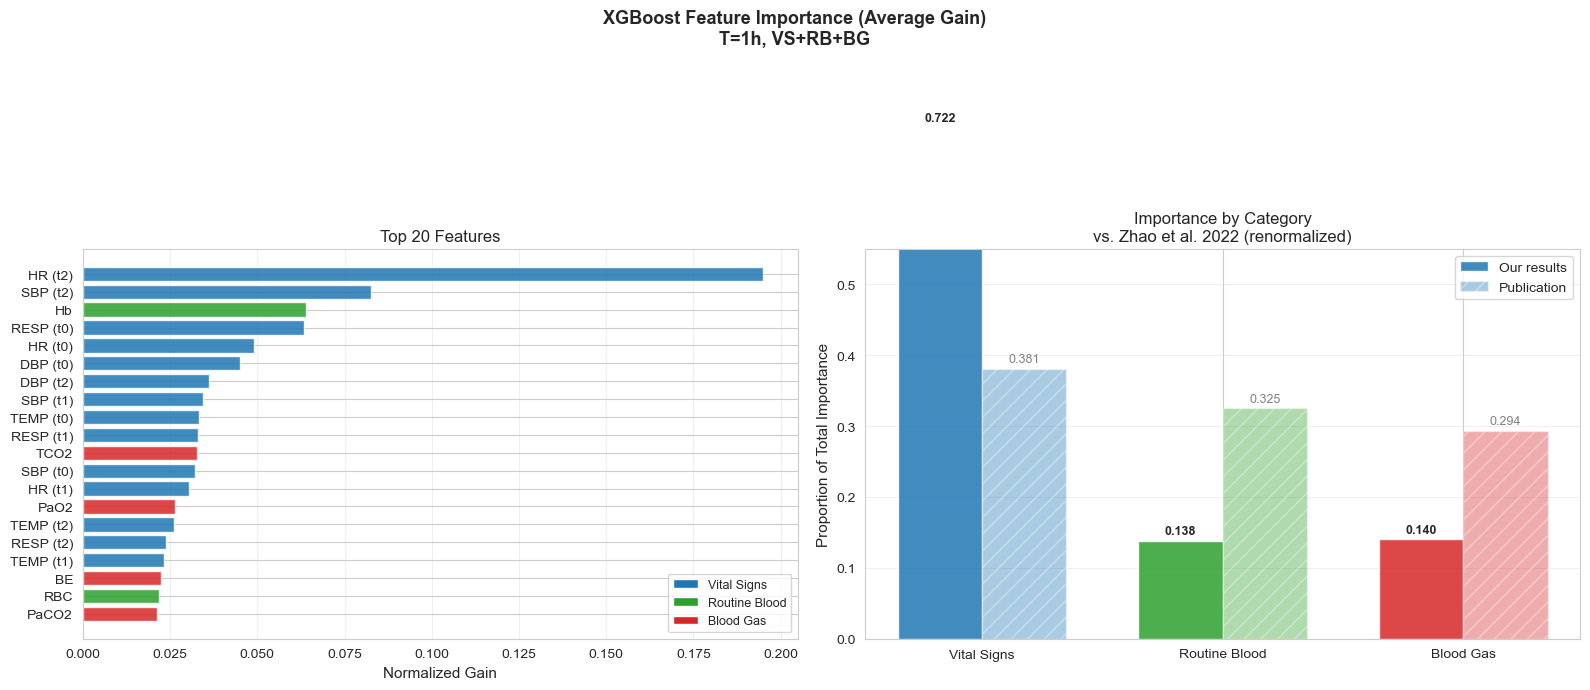

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('XGBoost Feature Importance (Average Gain)\nT=1h, VS+RB+BG',
             fontsize=13, fontweight='bold')

# ── Bar: top 20 features ──────────────────────────────────────────────────
ax = axes[0]
top20   = importance_df.head(20).iloc[::-1]
colors  = [CAT_COLORS[c] for c in top20['Category']]
ax.barh(top20['Display'], top20['Gain_norm'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Normalized Gain', fontsize=11)
ax.set_title('Top 20 Features', fontsize=12)
ax.grid(axis='x', alpha=0.3)
legend_el = [Patch(facecolor=CAT_COLORS[k], label=k) for k in ['Vital Signs','Routine Blood','Blood Gas']]
ax.legend(handles=legend_el, loc='lower right', fontsize=9)

# ── Bar: proporcje kategorii vs publikacja ────────────────────────────────
ax2 = axes[1]
cats    = ['Vital Signs','Routine Blood','Blood Gas']
our_vals = [cat_importance[c] for c in cats]
pub_vals = [PUB_IMPORTANCE[c] for c in cats]
x, w = np.arange(3), 0.35
col = [CAT_COLORS[c] for c in cats]

ax2.bar(x - w/2, our_vals, w, color=col, alpha=0.85, label='Our results')
ax2.bar(x + w/2, pub_vals, w, color=col, alpha=0.38, hatch='//', label='Publication')
ax2.set_xticks(x); ax2.set_xticklabels(cats, fontsize=10)
ax2.set_ylabel('Proportion of Total Importance', fontsize=11)
ax2.set_title('Importance by Category\nvs. Zhao et al. 2022 (renormalized)', fontsize=12)
ax2.legend(fontsize=10); ax2.grid(axis='y', alpha=0.3); ax2.set_ylim(0, 0.55)
for i, (o, p) in enumerate(zip(our_vals, pub_vals)):
    ax2.text(i-w/2, o+0.005, f'{o:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.text(i+w/2, p+0.005, f'{p:.3f}', ha='center', va='bottom', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'feature_importance_gain.png', bbox_inches='tight')
plt.show()


## Faza 3 — Obliczenie wartości SHAP

In [6]:
print(f"Computing SHAP values on {len(X_sample)} samples using XGBoost native C++ engine...")

# 🟢 OMIJAMY BŁĄD PARSERA: Używamy wbudowanego silnika XGBoost
booster = model.get_booster()
dmatrix = xgb.DMatrix(X_sample)

# pred_contribs=True zwraca macierz o wymiarach (n_samples, n_features + 1)
# Gdzie ostatnia kolumna to 'bias' (wartość bazowa / expected_value).
shap_contribs = booster.predict(dmatrix, pred_contribs=True)

# Wyodrębniamy same wartości SHAP dla cech (odrzucamy ostatnią kolumnę)
shap_values = shap_contribs[:, :-1]

# Wartość oczekiwana (expected_value) znajduje się w ostatniej kolumnie
expected_value = shap_contribs[0, -1]

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value:    {expected_value:.4f}")

mean_abs = np.abs(shap_values).mean(axis=0)
print("\nTop 5 features by mean |SHAP|:")
for i in np.argsort(mean_abs)[-5:][::-1]:
    # Używamy słownika FEATURE_DISPLAY (jeśli zdefiniowany) lub samej nazwy cechy
    disp_name = FEATURE_DISPLAY.get(feature_names[i], feature_names[i]) if 'FEATURE_DISPLAY' in globals() else feature_names[i]
    print(f"  {disp_name:<14}: {mean_abs[i]:.4f}")

Computing SHAP values on 500 samples using XGBoost native C++ engine...
SHAP values shape: (500, 26)
Expected value:    -2.1152

Top 5 features by mean |SHAP|:
  HR (t2)       : 1.9819
  SBP (t2)      : 0.9084
  HR (t0)       : 0.6221
  RBC           : 0.5581
  SBP (t1)      : 0.3827


## SHAP Summary (beeswarm)

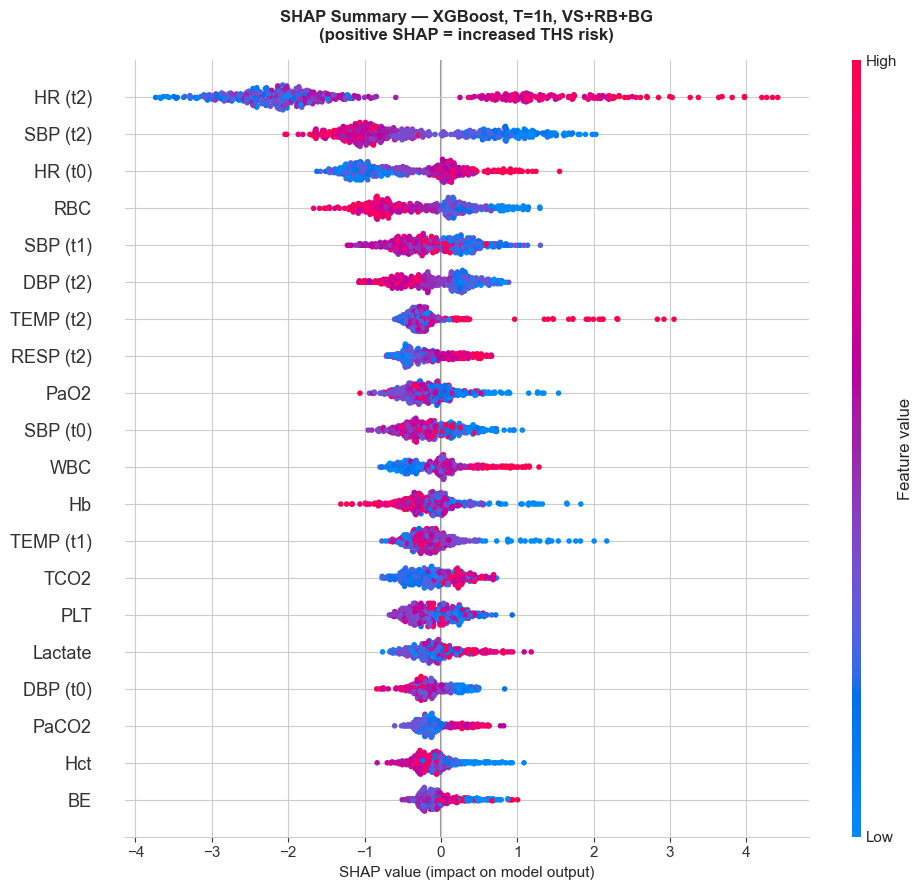

In [7]:
feat_display = [FEATURE_DISPLAY.get(f, f) for f in feature_names]

fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feat_display,
    show=False, max_display=20, plot_size=None,
)
plt.gca().set_title('SHAP Summary — XGBoost, T=1h, VS+RB+BG\n'
                    '(positive SHAP = increased THS risk)',
                    fontsize=12, fontweight='bold', pad=15)
plt.gca().set_xlabel('SHAP value (impact on model output)', fontsize=11)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'shap_summary_beeswarm.png', bbox_inches='tight')
plt.show()


## SHAP Bar — Mean |SHAP|

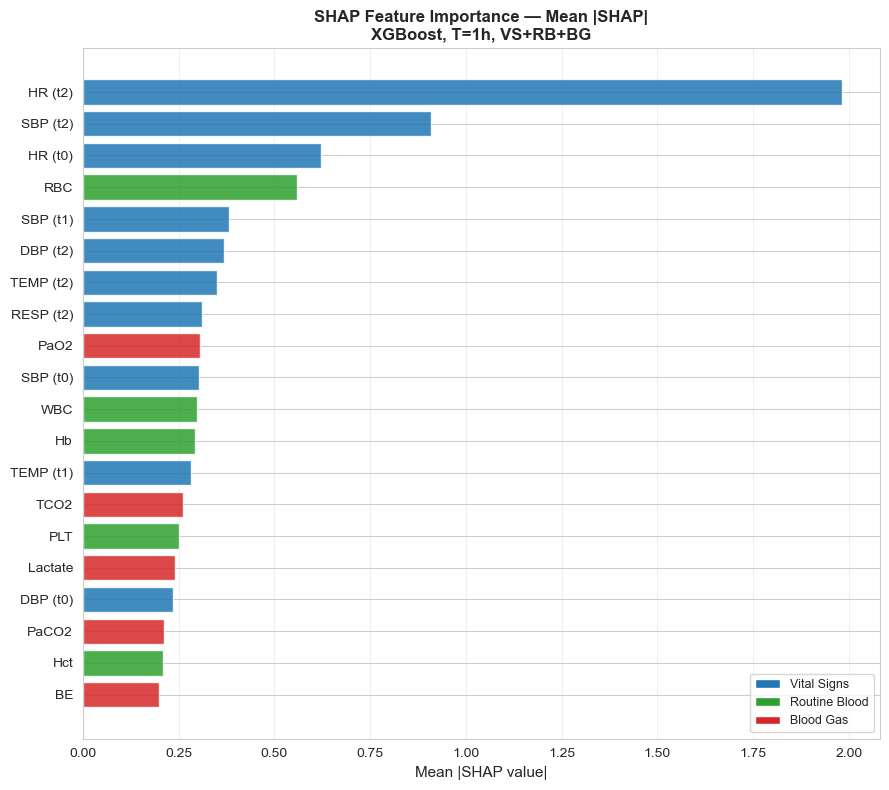

Saved: shap_bar_mean_abs.png + shap_importance_T1h.csv


In [8]:
mean_shap_df = pd.DataFrame({
    'Feature':  feat_display,
    'MeanSHAP': mean_abs,
    'Category': [assign_category(f) for f in feature_names],
}).sort_values('MeanSHAP', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 8))
plot_df = mean_shap_df.head(20).iloc[::-1]
colors  = [CAT_COLORS[c] for c in plot_df['Category']]
ax.barh(plot_df['Feature'], plot_df['MeanSHAP'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('SHAP Feature Importance — Mean |SHAP|\nXGBoost, T=1h, VS+RB+BG',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
legend_el = [Patch(facecolor=CAT_COLORS[k], label=k) for k in ['Vital Signs','Routine Blood','Blood Gas']]
ax.legend(handles=legend_el, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'shap_bar_mean_abs.png', bbox_inches='tight')
plt.show()

mean_shap_df.to_csv(config.RESULTS_DIR / 'shap_importance_T1h.csv', index=False)
print("Saved: shap_bar_mean_abs.png + shap_importance_T1h.csv")


## Faza 4 — SHAP Dependence Plots (replikacja Fig. 3)

Oś X = wartość cechy, Oś Y = wartość SHAP (wpływ na predykcję THS).


In [9]:
# Wybierz top features per kategoria (sortuj po mean |SHAP|)
top_per_cat = {}
for cat, feats in FEATURE_CATEGORIES.items():
    candidates = []
    for f in feature_names:
        base = f.split('_t')[0]
        if base in feats:
            candidates.append((f, feature_names.index(f), mean_abs[feature_names.index(f)]))
    top_per_cat[cat] = sorted(candidates, key=lambda x: -x[2])

print("Top features per category (sorted by mean |SHAP|):")
for cat, feats in top_per_cat.items():
    top3 = [f"{f} ({v:.4f})" for f, _, v in feats[:3]]
    print(f"  {cat}: {top3}")


Top features per category (sorted by mean |SHAP|):
  Vital Signs: ['HR_t2 (1.9819)', 'SBP_t2 (0.9084)', 'HR_t0 (0.6221)']
  Routine Blood: ['RBC (0.5581)', 'WBC (0.2991)', 'Hemoglobin (0.2933)']
  Blood Gas: ['PaO2 (0.3057)', 'TCO2 (0.2625)', 'Lactate (0.2397)']


### Vital Signs — dependence plots (t0)

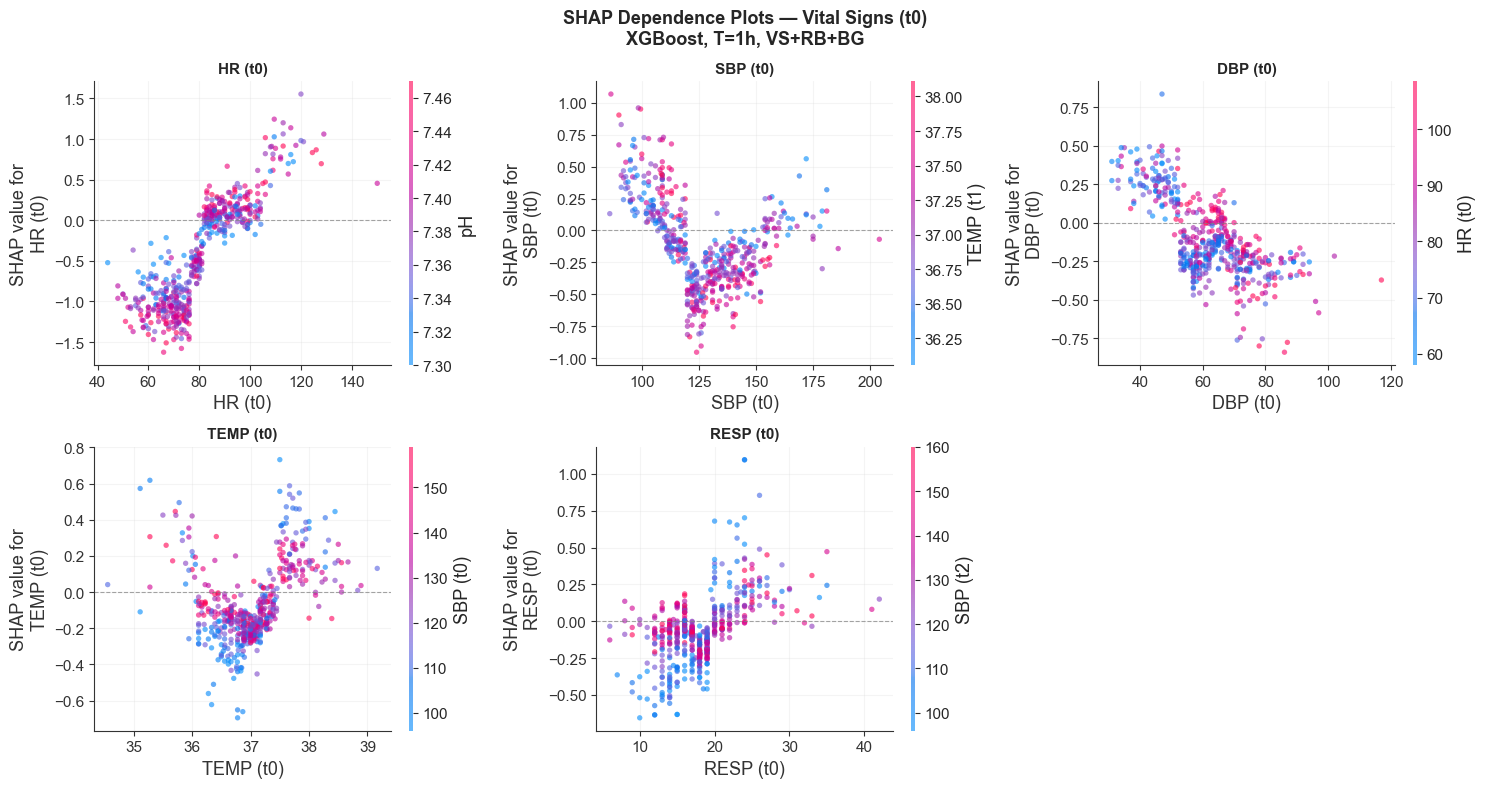

Saved: shap_dependence_vital_signs.png


In [10]:
# Vital Signs: top 5 zmiennych w timestepie t0
vs_features = [f for f, idx, _ in top_per_cat['Vital Signs'] if '_t0' in f][:5]

n_cols = 3
n_rows = int(np.ceil(len(vs_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
fig.suptitle('SHAP Dependence Plots — Vital Signs (t0)\nXGBoost, T=1h, VS+RB+BG',
             fontsize=13, fontweight='bold')

for i, feat in enumerate(vs_features):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_sample,
        feature_names=feat_display,
        ax=axes[i], show=False, dot_size=15, alpha=0.6,
    )
    axes[i].axhline(0, color='gray', linestyle='--', lw=0.8, alpha=0.7)
    axes[i].set_title(FEATURE_DISPLAY.get(feat, feat), fontsize=11, fontweight='bold')
    axes[i].grid(alpha=0.2)

for j in range(len(vs_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'shap_dependence_vital_signs.png', bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_vital_signs.png")


### Routine Blood + Blood Gas — dependence plots

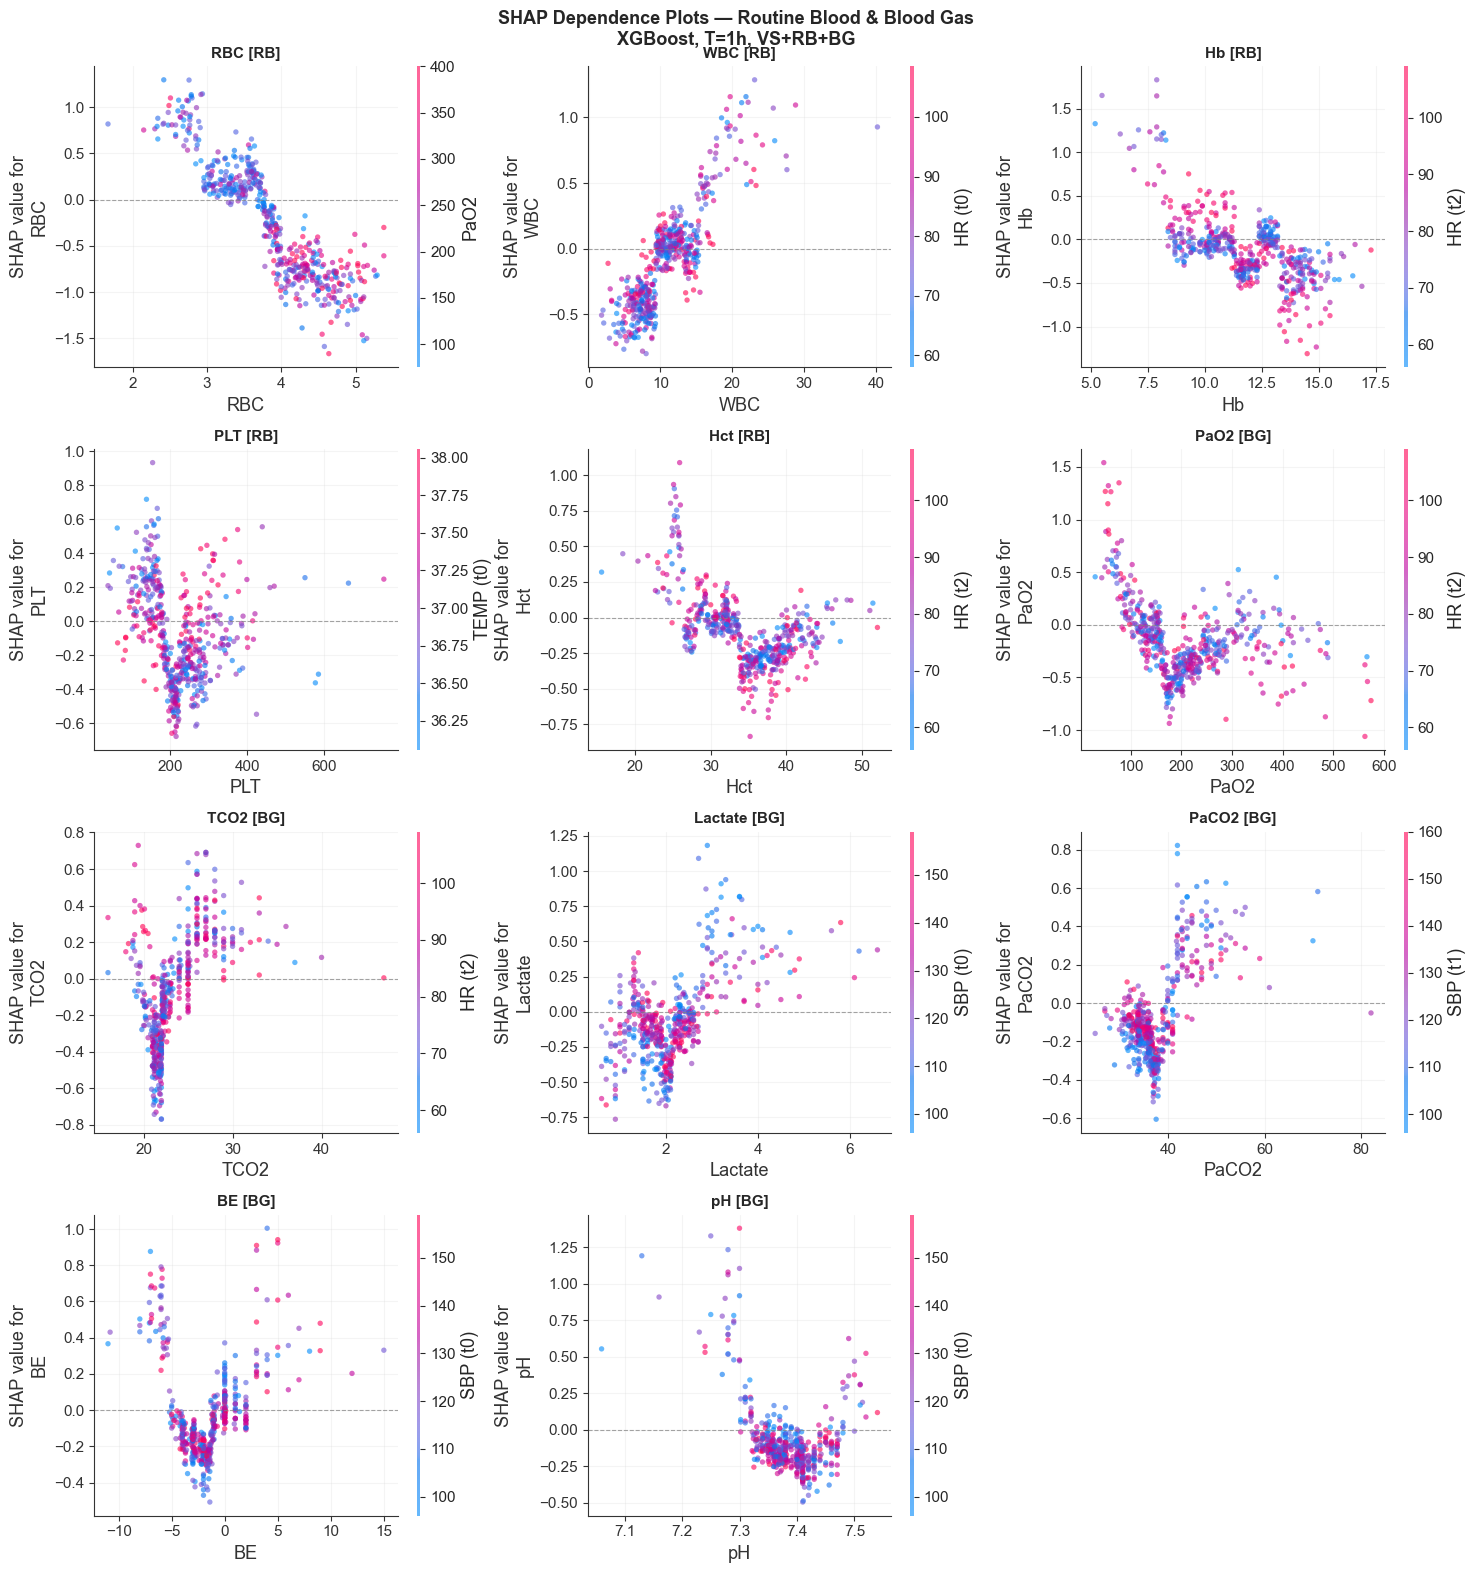

Saved: shap_dependence_lab_values.png


In [11]:
rb_features = [f for f, idx, _ in top_per_cat['Routine Blood']][:5]
bg_features = [f for f, idx, _ in top_per_cat['Blood Gas']][:6]
rb_bg_features = rb_features + bg_features

n_cols = 3
n_rows = int(np.ceil(len(rb_bg_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
fig.suptitle('SHAP Dependence Plots — Routine Blood & Blood Gas\nXGBoost, T=1h, VS+RB+BG',
             fontsize=13, fontweight='bold')

for i, feat in enumerate(rb_bg_features):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_sample,
        feature_names=feat_display,
        ax=axes[i], show=False, dot_size=15, alpha=0.6,
    )
    axes[i].axhline(0, color='gray', linestyle='--', lw=0.8, alpha=0.7)
    cat = assign_category(feat)
    tag = {'Routine Blood':'[RB]', 'Blood Gas':'[BG]'}.get(cat, '')
    axes[i].set_title(f"{FEATURE_DISPLAY.get(feat, feat)} {tag}", fontsize=11, fontweight='bold')
    axes[i].grid(alpha=0.2)

for j in range(len(rb_bg_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'shap_dependence_lab_values.png', bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_lab_values.png")


## Faza 5 — SHAP Waterfall dla przykładowych pacjentów

Jak model zdecydował dla konkretnego pacjenta — od wartości bazowej do finalnej predykcji.



THS patient (high confidence)
  True label: THS
  P(THS) = 1.000


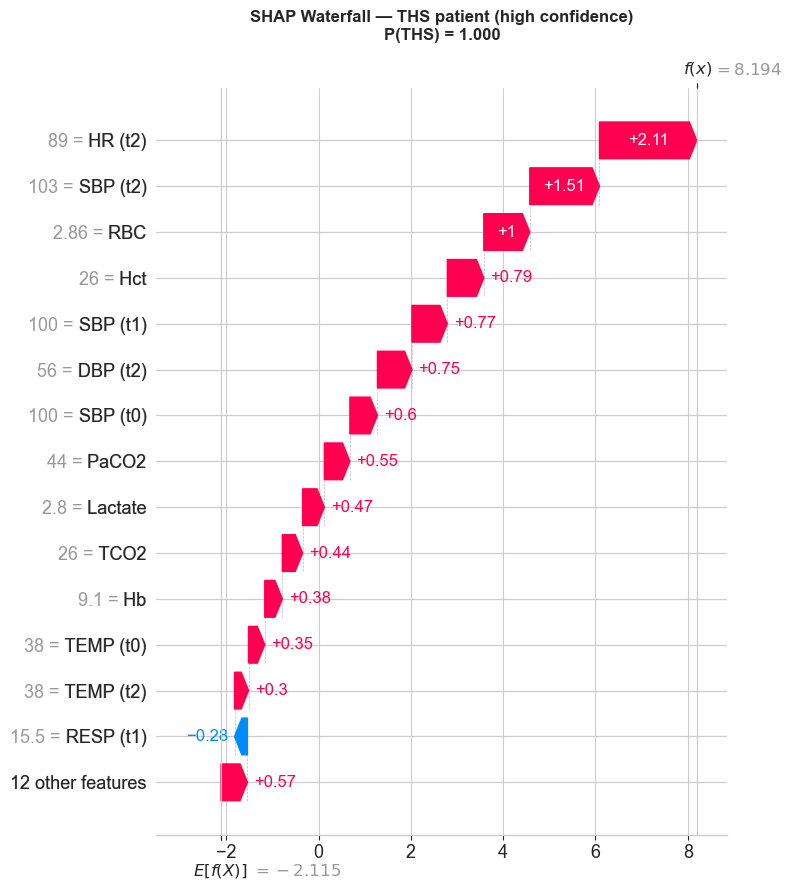

  Saved: shap_waterfall_ths.png

Non-THS patient (high confidence)
  True label: non-THS
  P(THS) = 0.000


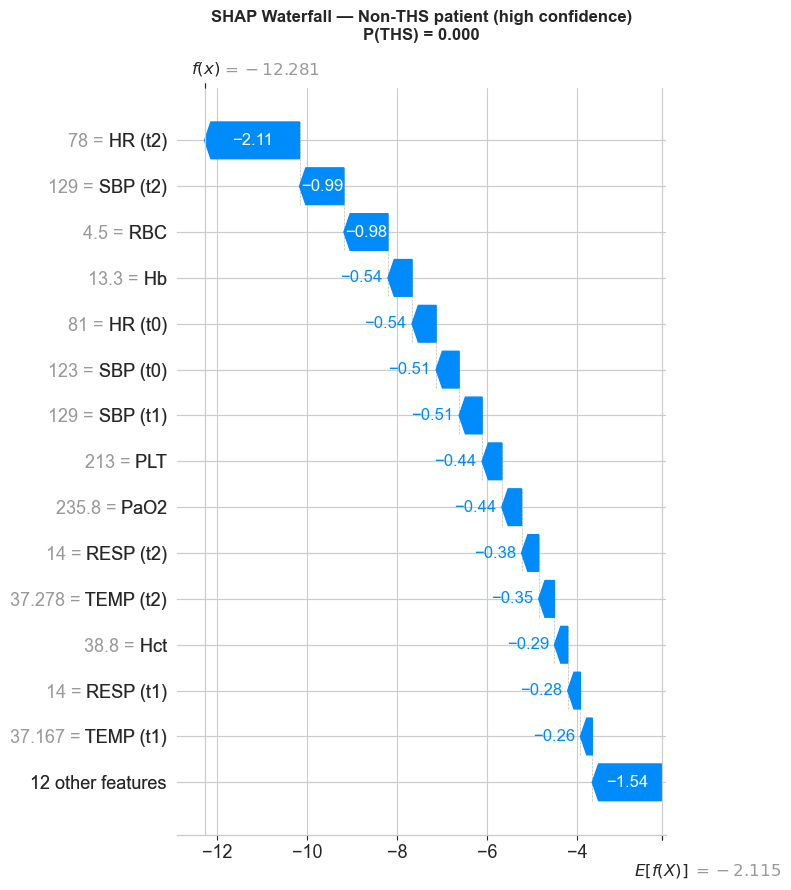

  Saved: shap_waterfall_nonths.png


In [12]:
y_pred_proba = model.predict_proba(X_sample)[:, 1]

ths_idx     = np.where(y_sample == 1)[0]
non_ths_idx = np.where(y_sample == 0)[0]

ths_example     = ths_idx[np.argmax(y_pred_proba[ths_idx])]
non_ths_example = non_ths_idx[np.argmin(y_pred_proba[non_ths_idx])]

for label, idx, title_suffix, fname in [
    (1, ths_example,     'THS patient (high confidence)',    'shap_waterfall_ths.png'),
    (0, non_ths_example, 'Non-THS patient (high confidence)','shap_waterfall_nonths.png'),
]:
    prob = y_pred_proba[idx]
    print(f"\n{title_suffix}")
    print(f"  True label: {'THS' if label == 1 else 'non-THS'}")
    print(f"  P(THS) = {prob:.3f}")

    explanation = shap.Explanation(
        values      = shap_values[idx],
        base_values = expected_value,   # 🟢 POPRAWKA: Używamy zmiennej z poprzedniej komórki
        data        = X_sample[idx],
        feature_names = feat_display,
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.waterfall_plot(explanation, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {title_suffix}\nP(THS) = {prob:.3f}',
              fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {fname}")

## Podsumowanie

In [13]:
print("✅ Evaluation pipeline complete.")
print()
print("Saved figures:")
for f in sorted(config.FIGURES_DIR.glob('*.png')):
    print(f"  {f.name}")
print()
print("Saved results:")
for f in sorted(config.RESULTS_DIR.glob('*.csv')):
    print(f"  {f.name}")


✅ Evaluation pipeline complete.

Saved figures:
  01_admissions_overview.png
  02_patients_age.png
  03_diagnoses_trauma.png
  04_vitals_distributions.png
  05_labs_routine.png
  06_labs_bloodgas.png
  eda_shock_H1_time.png
  eda_shock_H3_map_coverage.png
  feature_importance_gain.png
  imputation_impact.png
  roc_curves_test.png
  shap_bar_mean_abs.png
  shap_dependence_lab_values.png
  shap_dependence_vital_signs.png
  shap_summary_beeswarm.png
  shap_summary_xgb.png
  shap_waterfall_nonths.png
  shap_waterfall_ths.png

Saved results:
  delong_test_results.csv
  feature_importance.csv
  modeling_results.csv
  shap_importance_T1h.csv
